# FASE 4: Ingeniería de Características (Feature Engineering)

Objetivo: Diseñar la **variable objetivo** (riesgo de diabetes) y seleccionar/crear las **variables predictoras clave** a partir de los 3 datasets limpios de la FASE 3.

**Clasificación objetivo (criterios ADA/OMS):**
- **0 = Sin riesgo**: HbA1c < 5.7% Y Glucosa en ayunas < 100 mg/dL
- **1 = Prediabetes**: HbA1c 5.7-6.4% O Glucosa en ayunas 100-125 mg/dL
- **2 = Diabetes**: HbA1c >= 6.5% O Glucosa en ayunas >= 126 mg/dL

**Etapas:**
1. Consolidación de variables relevantes de los 3 datasets
2. Creación de la variable objetivo (DIABETES_RISK)
3. Ingeniería de nuevas características
4. **Validación visual y estadística** de la selección de variables
5. Guardado del dataset final para modelado

In [1]:
%load_ext kedro.ipython

[06/13/26 18:14:13] INFO     Using                                                                  ]8;id=885247;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=73922;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=360166;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=952296;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=86375;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=919834;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=248509;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=686556;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\alarc\OneDrive\Escritorio\Proyecto_Nhanes_Kedro\proyecto_nhan                
                             es_kedro.                                                                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/13/26 18:14:15] WARNING  c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packag ]8;id=793450;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=551794;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\warnings.py#112\112]8;;\
                             es\kedro\framework\project\__init__.py:350: UserWarning: The                          
                             'proyecto_nhanes_kedro.pipelines.data_science' module does not expose                 
                             a 'create_pipeline' function, so no pipelines defined therein will be                 
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    WARNING  c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packag ]8;id=827915;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=472025;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\warnings.py#112\112]8;;\
                             es\kedro\framework\project\__init__.py:350: UserWarning: The                          
                             'proyecto_nhanes_kedro.pipelines.feature_engineering' module does not                 
                             expose a 'create_pipeline' function, so no pipelines defined therein                  
                             will be returned by 'find_pipelines'.                                                 
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=285194;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=85090;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/13/26 18:14:16] INFO     Kedro project Proyecto NHANES Kedro                                    ]8;id=170330;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=953285;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=894710;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=555639;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Cargar datasets limpios
df_dietary = catalog.load('demodietary_clean')
df_examination = catalog.load('demoexamination_clean')
df_laboratory = catalog.load('demolaboratory_clean')

print('--- SHAPES DE ENTRADA (Post-Limpieza FASE 3) ---')
print(f'DemoDietary Clean:     {df_dietary.shape}')
print(f'DemoExamination Clean: {df_examination.shape}')
print(f'DemoLaboratory Clean:  {df_laboratory.shape}')

[06/13/26 18:14:30] INFO     Loading data from demodietary_clean (ParquetDataset)...           ]8;id=875415;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=195032;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from demoexamination_clean (ParquetDataset)...       ]8;id=220817;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=853439;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from demolaboratory_clean (ParquetDataset)...        ]8;id=549836;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=708935;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

--- SHAPES DE ENTRADA (Post-Limpieza FASE 3) ---
DemoDietary Clean:     (7521, 357)
DemoExamination Clean: (8366, 197)
DemoLaboratory Clean:  (7517, 217)


## Paso 4.1: Identificación de Variables Clave por Sección

Seleccionamos columnas con mayor relevancia clínica documentada para predicción de diabetes.

In [3]:
# === VARIABLES DEMOGRAFICAS ===
demo_cols = [
    'SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR',
]

# === VARIABLES DE LABORATORIO ===
lab_cols = [
    'SEQN',
    'LBXGH',       # HbA1c (target builder)
    'LBXGLU',      # Glucosa en ayunas (target builder)
    'LBXIN',       # Insulina
    'LBXTR',       # Triglicéridos
    'LBDHDD',      # HDL Colesterol
    'LBXTC',       # Colesterol Total
    'LBXSCR',      # Creatinina sérica
    'LBXSUA',      # Ácido Úrico
    'LBXSTP',      # Proteína Total
    'LBXSAL',      # Albúmina
    'LBXSBU',      # BUN
    'LBXSCA',      # Calcio
    'LBXSC3SI',    # Bicarbonato
    'LBXSKSI',     # Potasio
    'LBXSNASI',    # Sodio
    'LBXWBCSI',    # Leucocitos
    'LBXHGB',      # Hemoglobina
    'LBXHCT',      # Hematocrito
    'LBXRDW',      # RDW
    'LBXPLTSI',    # Plaquetas
    'LBXCRP',      # PCR
    'URXUMA',      # Albúmina urinaria
    'URXUCR',      # Creatinina urinaria
]

# === VARIABLES DE EXAMEN FÍSICO ===
exam_cols = [
    'SEQN',
    'BMXBMI', 'BMXWAIST', 'BMXHT', 'BMXWT',
    'BPXOSY1', 'BPXOSY2', 'BPXOSY3',
    'BPXODI1', 'BPXODI2', 'BPXODI3',
]

# === VARIABLES DE DIETA ===
diet_cols = [
    'SEQN',
    'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TTFAT',
    'DR1TSFAT', 'DR1TFIBE', 'DR1TSUGR', 'DR1TSODI',
]

def safe_select(df, cols, name):
    available = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    print(f'{name}: {len(available)}/{len(cols)} columnas encontradas.')
    if missing:
        print(f'  Faltantes: {missing}')
    return df[available]

df_lab_sel = safe_select(df_laboratory, lab_cols, 'Laboratory')
df_exam_sel = safe_select(df_examination, exam_cols, 'Examination')
df_diet_sel = safe_select(df_dietary, diet_cols, 'Dietary')
df_demo_sel = safe_select(df_laboratory, demo_cols, 'Demographics')

Laboratory: 20/24 columnas encontradas.
  Faltantes: ['LBXGLU', 'LBXIN', 'LBXTR', 'LBXCRP']
Examination: 11/11 columnas encontradas.
Dietary: 9/9 columnas encontradas.
Demographics: 6/6 columnas encontradas.


## Paso 4.2: Consolidación en Dataset Analítico

In [4]:
# Merge: Demo + Lab
df_analytic = df_demo_sel.merge(df_lab_sel, on='SEQN', how='inner', suffixes=('', '_dup'))
df_analytic = df_analytic[[c for c in df_analytic.columns if not c.endswith('_dup')]]

# Merge: + Examen
exam_to_merge = df_exam_sel.drop(columns=[c for c in df_exam_sel.columns if c in df_analytic.columns and c != 'SEQN'])
df_analytic = df_analytic.merge(exam_to_merge, on='SEQN', how='left')

# Merge: + Dieta
diet_to_merge = df_diet_sel.drop(columns=[c for c in df_diet_sel.columns if c in df_analytic.columns and c != 'SEQN'])
df_analytic = df_analytic.merge(diet_to_merge, on='SEQN', how='left')

print(f'Dataset analítico consolidado: {df_analytic.shape}')
print(f'SEQN únicos: {df_analytic["SEQN"].nunique()}')

Dataset analítico consolidado: (7517, 43)
SEQN únicos: 7517


## Paso 4.3: Creación de la Variable Objetivo (DIABETES_RISK)

In [5]:
def create_diabetes_target(df):
    df = df.copy()
    df['DIABETES_RISK'] = np.nan
    
    hba1c = df.get('LBXGH')
    glucose = df.get('LBXGLU')
    
    diabetes_mask = pd.Series(False, index=df.index)
    prediabetes_mask = pd.Series(False, index=df.index)
    no_risk_mask = pd.Series(False, index=df.index)
    
    if hba1c is not None:
        diabetes_mask = diabetes_mask | (hba1c >= 6.5)
        prediabetes_mask = prediabetes_mask | ((hba1c >= 5.7) & (hba1c < 6.5))
        no_risk_mask = no_risk_mask | (hba1c < 5.7)
    
    if glucose is not None:
        diabetes_mask = diabetes_mask | (glucose >= 126)
        prediabetes_mask = prediabetes_mask | ((glucose >= 100) & (glucose < 126))
        no_risk_mask = no_risk_mask | (glucose < 100)
    
    df.loc[no_risk_mask, 'DIABETES_RISK'] = 0
    df.loc[prediabetes_mask, 'DIABETES_RISK'] = 1
    df.loc[diabetes_mask, 'DIABETES_RISK'] = 2
    df['DIABETES_RISK'] = df['DIABETES_RISK'].astype('Int64')
    
    print('=== DISTRIBUCIÓN VARIABLE OBJETIVO ===')
    labels = {0: 'Sin riesgo', 1: 'Prediabetes', 2: 'Diabetes'}
    for val, count in df['DIABETES_RISK'].value_counts().sort_index().items():
        pct = count / len(df) * 100
        print(f'  {val} ({labels.get(val)}): {count:,} ({pct:.1f}%)')
    null_count = df['DIABETES_RISK'].isna().sum()
    print(f'  NaN: {null_count:,} ({null_count/len(df)*100:.1f}%)')
    return df

df_analytic = create_diabetes_target(df_analytic)

=== DISTRIBUCIÓN VARIABLE OBJETIVO ===
  0 (Sin riesgo): 3,659 (48.7%)
  1 (Prediabetes): 1,635 (21.8%)
  2 (Diabetes): 751 (10.0%)
  NaN: 1,472 (19.6%)


## Paso 4.4: Ingeniería de Nuevas Características

In [6]:
def engineer_features(df):
    df = df.copy()
    
    # 1. HOMA-IR (resistencia a la insulina)
    if 'LBXGLU' in df.columns and 'LBXIN' in df.columns:
        df['HOMA_IR'] = (df['LBXGLU'] * df['LBXIN']) / 405
        print(f'HOMA_IR creado. Mediana: {df["HOMA_IR"].median():.2f}')
    
    # 2. Ratio Cintura/Estatura
    if 'BMXWAIST' in df.columns and 'BMXHT' in df.columns:
        df['WAIST_HEIGHT_RATIO'] = df['BMXWAIST'] / df['BMXHT']
        print(f'WAIST_HEIGHT_RATIO creado. Mediana: {df["WAIST_HEIGHT_RATIO"].median():.3f}')
    
    # 3. Presión Arterial Media (MAP)
    sys_cols = [c for c in ['BPXOSY1', 'BPXOSY2', 'BPXOSY3'] if c in df.columns]
    dia_cols = [c for c in ['BPXODI1', 'BPXODI2', 'BPXODI3'] if c in df.columns]
    if sys_cols and dia_cols:
        df['BP_SYSTOLIC_AVG'] = df[sys_cols].mean(axis=1)
        df['BP_DIASTOLIC_AVG'] = df[dia_cols].mean(axis=1)
        df['MAP'] = df['BP_DIASTOLIC_AVG'] + (1/3) * (df['BP_SYSTOLIC_AVG'] - df['BP_DIASTOLIC_AVG'])
        print(f'MAP creado. Mediana: {df["MAP"].median():.1f}')
    
    # 4. Categoría de IMC
    if 'BMXBMI' in df.columns:
        df['BMI_CATEGORY'] = pd.cut(
            df['BMXBMI'],
            bins=[0, 18.5, 25, 30, 35, 40, 100],
            labels=[0, 1, 2, 3, 4, 5]
        ).astype('Int64')
        print(f'BMI_CATEGORY creado.')
    
    # 5. Ratio Triglicéridos / HDL
    if 'LBXTR' in df.columns and 'LBDHDD' in df.columns:
        df['TG_HDL_RATIO'] = df['LBXTR'] / df['LBDHDD']
        print(f'TG_HDL_RATIO creado. Mediana: {df["TG_HDL_RATIO"].median():.2f}')
    
    # 6. Ratio Albúmina/Creatinina Urinaria (ACR)
    if 'URXUMA' in df.columns and 'URXUCR' in df.columns:
        df['ACR'] = (df['URXUMA'] / df['URXUCR']) * 100
        print(f'ACR creado. Mediana: {df["ACR"].median():.2f}')
    
    # 7. Grupo de Edad
    if 'RIDAGEYR' in df.columns:
        df['AGE_GROUP'] = pd.cut(
            df['RIDAGEYR'],
            bins=[0, 20, 40, 60, 80, 120],
            labels=[0, 1, 2, 3, 4]
        ).astype('Int64')
        print(f'AGE_GROUP creado.')
    
    # 8. Ratio Carbohidratos/Fibra
    if 'DR1TCARB' in df.columns and 'DR1TFIBE' in df.columns:
        df['CARB_FIBER_RATIO'] = df['DR1TCARB'] / df['DR1TFIBE'].replace(0, np.nan)
        print(f'CARB_FIBER_RATIO creado. Mediana: {df["CARB_FIBER_RATIO"].median():.1f}')
    
    # 9. Colesterol No-HDL
    if 'LBXTC' in df.columns and 'LBDHDD' in df.columns:
        df['NON_HDL_CHOL'] = df['LBXTC'] - df['LBDHDD']
        print(f'NON_HDL_CHOL creado. Mediana: {df["NON_HDL_CHOL"].median():.1f}')
    
    # 10. eGFR estimado (función renal)
    if 'LBXSCR' in df.columns and 'RIDAGEYR' in df.columns and 'RIAGENDR' in df.columns:
        # Fórmula CKD-EPI simplificada
        k = np.where(df['RIAGENDR'] == 2, 0.7, 0.9)
        alpha = np.where(df['RIAGENDR'] == 2, -0.329, -0.411)
        factor = np.where(df['RIAGENDR'] == 2, 1.018, 1.0)
        scr_k = df['LBXSCR'] / k
        df['eGFR'] = 141 * (np.minimum(scr_k, 1) ** alpha) * (np.maximum(scr_k, 1) ** (-1.209)) * (0.993 ** df['RIDAGEYR']) * factor
        print(f'eGFR creado. Mediana: {df["eGFR"].median():.1f}')
    
    return df

df_analytic = engineer_features(df_analytic)
print(f'\nShape tras Feature Engineering: {df_analytic.shape}')

WAIST_HEIGHT_RATIO creado. Mediana: 0.563
MAP creado. Mediana: 86.7
BMI_CATEGORY creado.
ACR creado. Mediana: 8.16
AGE_GROUP creado.
CARB_FIBER_RATIO creado. Mediana: 16.6
NON_HDL_CHOL creado. Mediana: 121.0
eGFR creado. Mediana: 97.3

Shape tras Feature Engineering: (7517, 54)


## Paso 4.5: Filtrado - Eliminar filas sin target y columnas de leakage

In [7]:
rows_before = len(df_analytic)
df_analytic = df_analytic.dropna(subset=['DIABETES_RISK']).reset_index(drop=True)
print(f'Filas eliminadas sin target: {rows_before - len(df_analytic)}')
print(f'Filas finales: {len(df_analytic)}')

# Eliminar variables de leakage (usadas para construir el target)
leakage_cols = ['LBXGH', 'LBXGLU']
df_analytic = df_analytic.drop(columns=[c for c in leakage_cols if c in df_analytic.columns])
print(f'Columnas de leakage eliminadas: {leakage_cols}')
print(f'Shape: {df_analytic.shape}')

Filas eliminadas sin target: 1472
Filas finales: 6045
Columnas de leakage eliminadas: ['LBXGH', 'LBXGLU']
Shape: (6045, 53)


---
## Paso 4.6: VALIDACIÓN DE SELECCIÓN DE VARIABLES

Aplicamos **4 métodos complementarios** para validar qué variables tienen mayor poder predictivo:
1. Heatmap de Correlación de Pearson
2. Información Mutua (Mutual Information)
3. ANOVA F-Test (SelectKBest)
4. Feature Importance con Random Forest

In [8]:
# Preparar datos para análisis: solo numéricas, sin SEQN
feature_cols = [c for c in df_analytic.select_dtypes(include=[np.number]).columns 
                if c not in ['SEQN', 'DIABETES_RISK']]
X_raw = df_analytic[feature_cols].copy()
y = df_analytic['DIABETES_RISK'].astype(float).copy()

# Imputar NaN con la mediana para los métodos de selección
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

print(f'Features para análisis: {len(feature_cols)}')
print(f'Muestras: {len(y)}')

Features para análisis: 51
Muestras: 6045


### 4.6.1: Heatmap de Correlación de Pearson con DIABETES_RISK

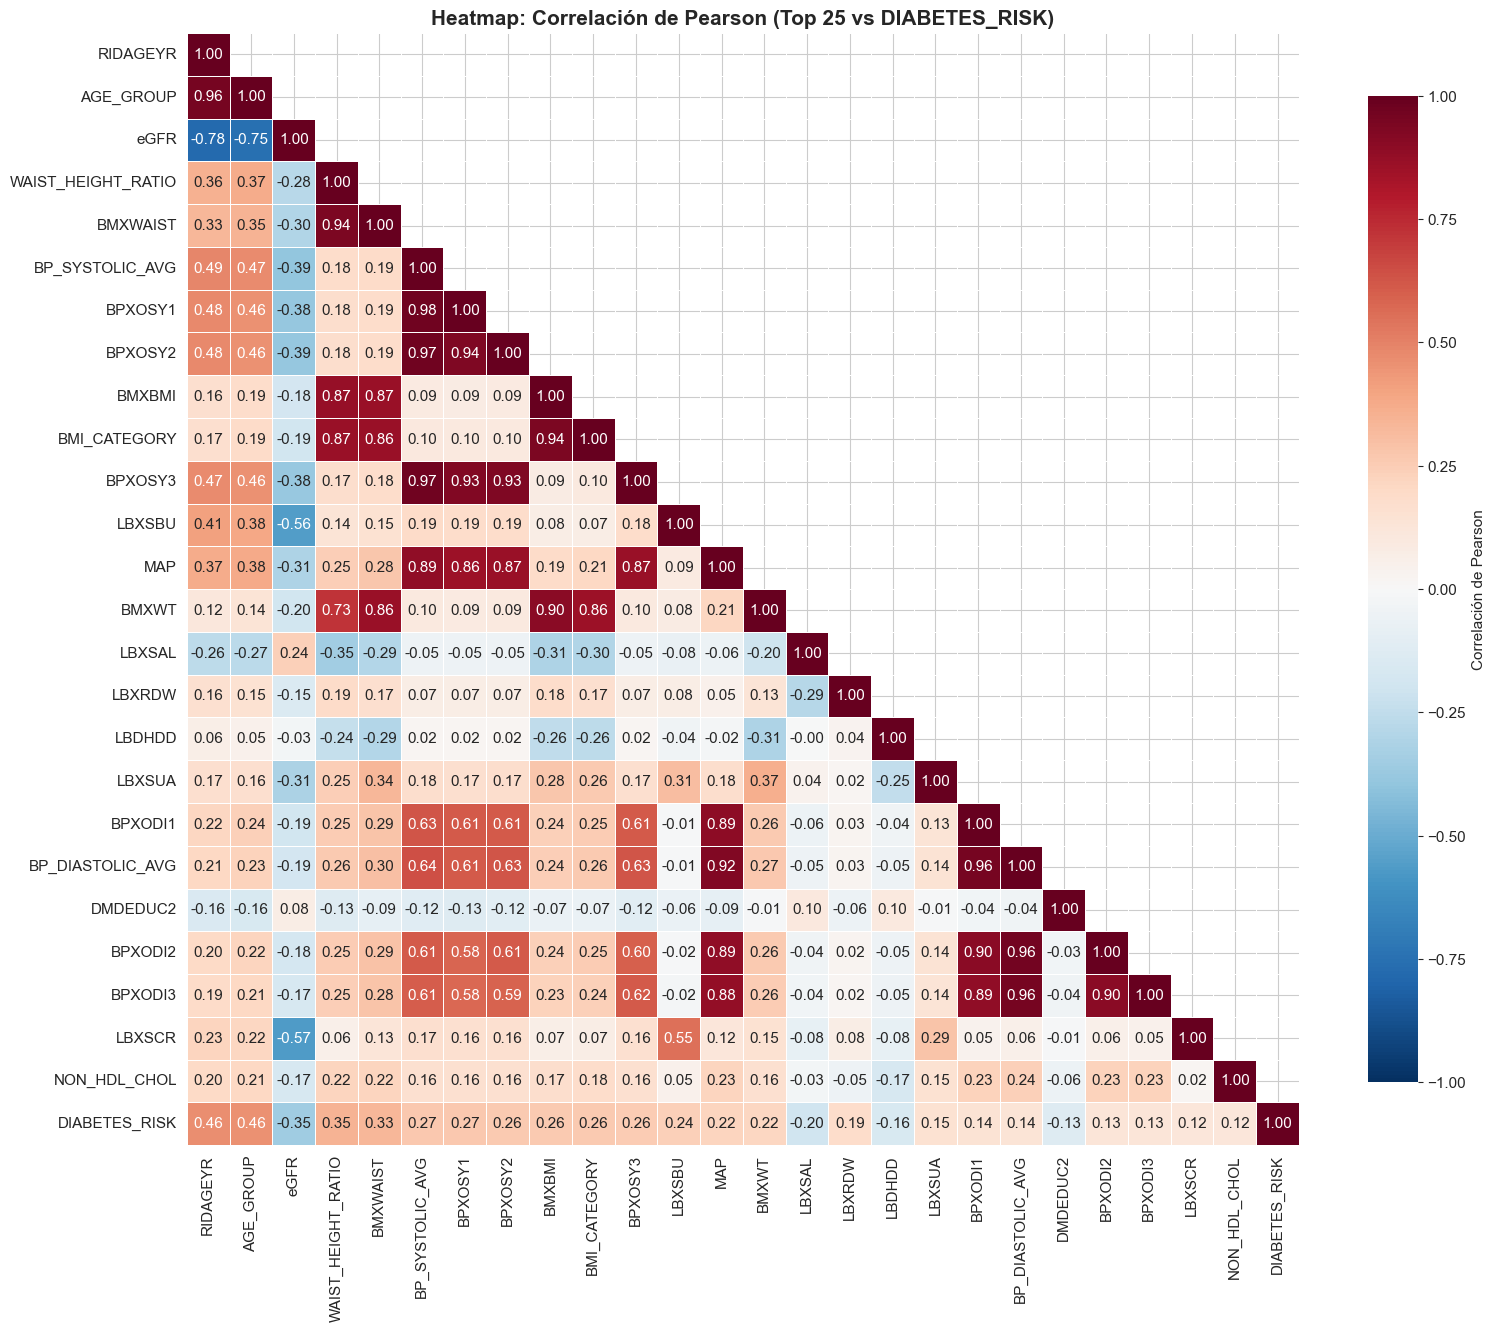


=== Top 25 Correlaciones con DIABETES_RISK ===
  RIDAGEYR                  -> +0.4611
  AGE_GROUP                 -> +0.4550
  eGFR                      -> -0.3524
  WAIST_HEIGHT_RATIO        -> +0.3459
  BMXWAIST                  -> +0.3300
  BP_SYSTOLIC_AVG           -> +0.2719
  BPXOSY1                   -> +0.2662
  BPXOSY2                   -> +0.2639
  BMXBMI                    -> +0.2592
  BMI_CATEGORY              -> +0.2591
  BPXOSY3                   -> +0.2571
  LBXSBU                    -> +0.2383
  MAP                       -> +0.2191
  BMXWT                     -> +0.2178
  LBXSAL                    -> -0.2020
  LBXRDW                    -> +0.1871
  LBDHDD                    -> -0.1581
  LBXSUA                    -> +0.1530
  BPXODI1                   -> +0.1417
  BP_DIASTOLIC_AVG          -> +0.1375
  DMDEDUC2                  -> -0.1307
  BPXODI2                   -> +0.1269
  BPXODI3                   -> +0.1267
  LBXSCR                    -> +0.1235
  NON_HDL_CHOL  

In [9]:
# Calcular correlaciones con el target
corr_with_target = X_imputed.assign(DIABETES_RISK=y.values).corr()['DIABETES_RISK'].drop('DIABETES_RISK')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

# Heatmap: Top 25 variables más correlacionadas
top_25 = corr_sorted.head(25).index.tolist()
corr_matrix = X_imputed[top_25].assign(DIABETES_RISK=y.values).corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
    ax=ax
)
ax.set_title('Heatmap: Correlación de Pearson (Top 25 vs DIABETES_RISK)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/heatmap_correlacion_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 25 Correlaciones con DIABETES_RISK ===')
for feat in top_25:
    val = corr_with_target[feat]
    print(f'  {feat:25s} -> {val:+.4f}')

### 4.6.2: Información Mutua (Mutual Information)

A diferencia de Pearson (solo relaciones lineales), la Información Mutua captura **cualquier tipo de dependencia** (lineal y no lineal) entre cada variable y el target.

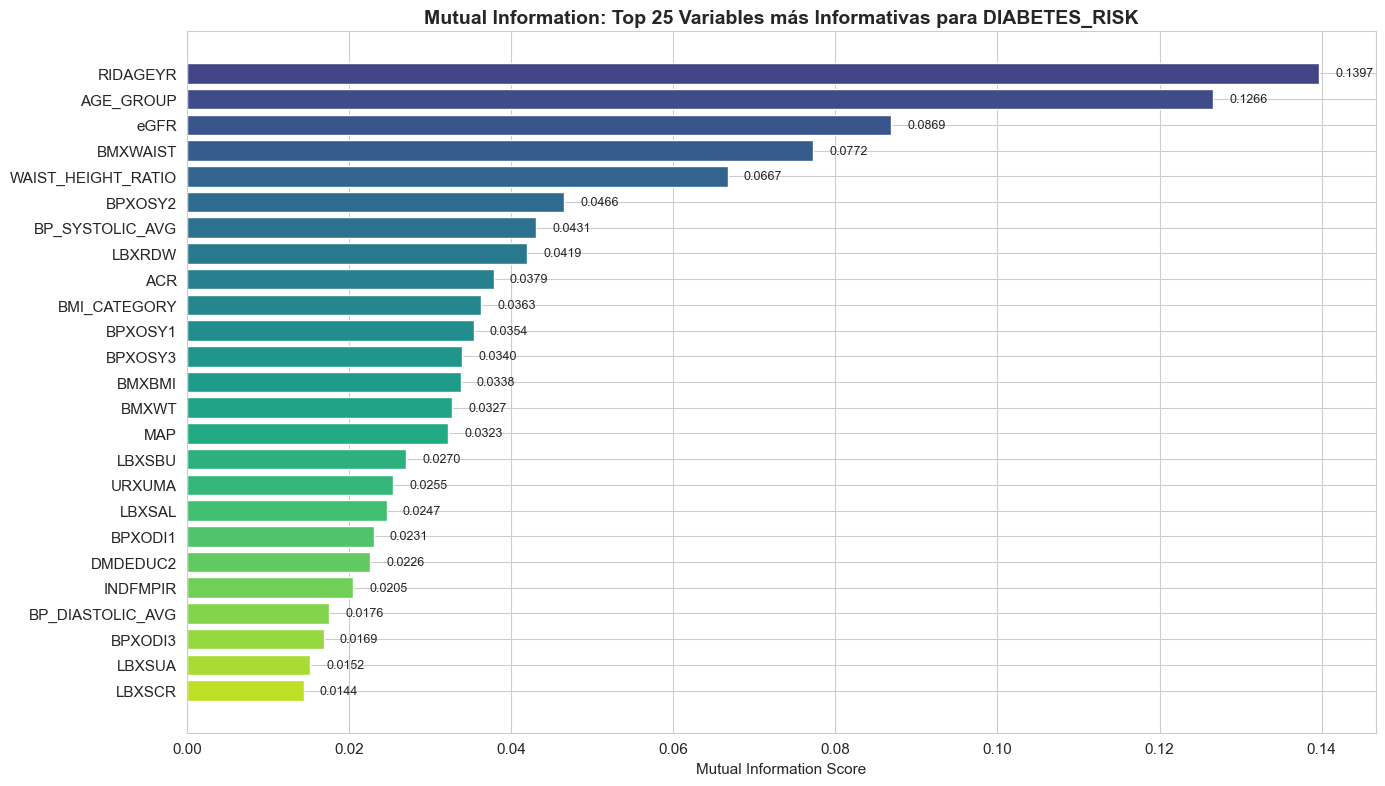

In [10]:
# Calcular Mutual Information
mi_scores = mutual_info_classif(X_imputed, y, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# Gráfico de barras: Top 25
fig, ax = plt.subplots(figsize=(14, 8))
top_25_mi = mi_series.head(25)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_25_mi)))
bars = ax.barh(range(len(top_25_mi)), top_25_mi.values, color=colors)
ax.set_yticks(range(len(top_25_mi)))
ax.set_yticklabels(top_25_mi.index)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information: Top 25 Variables más Informativas para DIABETES_RISK', fontsize=14, fontweight='bold')

for i, (val, name) in enumerate(zip(top_25_mi.values, top_25_mi.index)):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/08_reporting/mutual_information_top25.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6.3: ANOVA F-Test (SelectKBest)

Test estadístico que evalúa si las medias de cada variable difieren significativamente entre las clases del target. Un F-score alto indica alto poder discriminante.

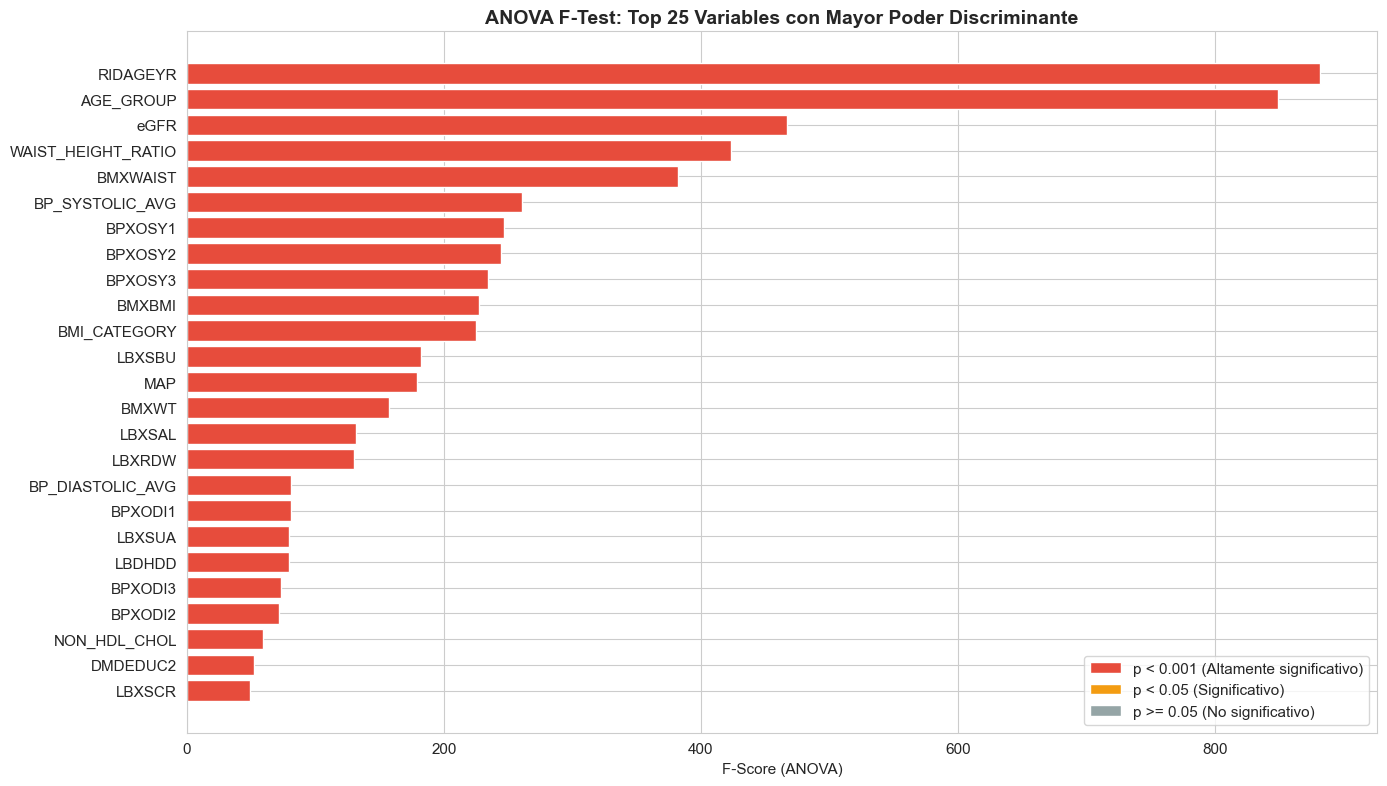

In [11]:
# ANOVA F-Test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_imputed, y)

f_scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)
p_values = pd.Series(selector.pvalues_, index=feature_cols)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 8))
top_25_f = f_scores.head(25)
colors = ['#e74c3c' if p_values[feat] < 0.001 else '#f39c12' if p_values[feat] < 0.05 else '#95a5a6' 
          for feat in top_25_f.index]
ax.barh(range(len(top_25_f)), top_25_f.values, color=colors)
ax.set_yticks(range(len(top_25_f)))
ax.set_yticklabels(top_25_f.index)
ax.invert_yaxis()
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title('ANOVA F-Test: Top 25 Variables con Mayor Poder Discriminante', fontsize=14, fontweight='bold')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='p < 0.001 (Altamente significativo)'),
    Patch(facecolor='#f39c12', label='p < 0.05 (Significativo)'),
    Patch(facecolor='#95a5a6', label='p >= 0.05 (No significativo)'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../data/08_reporting/anova_ftest_top25.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6.4: Feature Importance con Random Forest

Entrenamos un Random Forest rápido para obtener la importancia de cada variable basada en la reducción de impureza de Gini.

In [12]:
# Random Forest para Feature Importance
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_imputed, y)

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 8))
top_25_rf = rf_importance.head(25)
colors = plt.cm.magma(np.linspace(0.2, 0.85, len(top_25_rf)))
ax.barh(range(len(top_25_rf)), top_25_rf.values, color=colors)
ax.set_yticks(range(len(top_25_rf)))
ax.set_yticklabels(top_25_rf.index)
ax.invert_yaxis()
ax.set_xlabel('Importancia (Gini Importance)')
ax.set_title('Random Forest: Top 25 Feature Importances para DIABETES_RISK', fontsize=14, fontweight='bold')

for i, val in enumerate(top_25_rf.values):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/08_reporting/random_forest_importance_top25.png', dpi=150, bbox_inches='tight')
plt.show()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│    1 # Random Forest para Feature Importance                                                     │
│    2 rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,     │
│ ❱  3 rf.fit(X_imputed, y)                                                                        │
│    4                                                                                             │
│    5 rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascen    │
│    6                                                                                             │
│                                                                                                  │
│ c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336 in │
│ wrapper                                                                                          │
│                                                                                                  │
│ c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_fores │
│ t.py:374 in fit                                                                                  │
│                                                                                                  │
│ c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\tree\_classes.p │
│ y:225 in _compute_missing_values_in_feature_mask                                                 │
│                                                                                                  │
│ c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validatio │
│ n.py:182 in _assert_all_finite_element_wise                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ValueError: Input X contains infinity or a value too large for dtype('float32').

### 4.6.5: Consolidación de Rankings - Tabla Comparativa

Combinamos los 4 métodos en una tabla unificada para ver qué variables aparecen consistentemente en los tops.

In [ ]:
# Crear tabla comparativa de rankings
ranking_df = pd.DataFrame({
    'Pearson_Corr': corr_sorted.rank(ascending=False),
    'Mutual_Info': mi_series.rank(ascending=False),
    'ANOVA_F': f_scores.rank(ascending=False),
    'RF_Importance': rf_importance.rank(ascending=False),
})

# Ranking promedio
ranking_df['Avg_Rank'] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values('Avg_Rank')

# Mostrar Top 30
print('=== RANKING CONSOLIDADO: Top 30 Variables Más Relevantes ===')
print('(Menor Avg_Rank = Mayor importancia consistente entre los 4 métodos)\n')
print(ranking_df.head(30).to_string())

# Selección final: variables en el Top 25 promedio
final_features = ranking_df.head(25).index.tolist()
print(f'\nVariables seleccionadas para el modelo: {len(final_features)}')
print(final_features)

In [ ]:
# Heatmap final solo con las variables seleccionadas
fig, ax = plt.subplots(figsize=(18, 15))
selected_with_target = X_imputed[final_features].assign(DIABETES_RISK=y.values)
corr_final = selected_with_target.corr()

mask = np.triu(np.ones_like(corr_final, dtype=bool), k=1)
sns.heatmap(
    corr_final, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
    ax=ax
)
ax.set_title('Heatmap Final: Variables Seleccionadas + DIABETES_RISK', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/heatmap_final_seleccion.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 4.7: Reporte Final y Guardado como df_master

In [ ]:
# Dataset final con SEQN + features seleccionadas + target
final_cols = ['SEQN'] + final_features + ['DIABETES_RISK']
df_final = df_analytic[final_cols].copy()

print('=' * 60)
print('REPORTE FINAL - FASE 4: Feature Engineering')
print('=' * 60)
print(f'Shape del df_master: {df_final.shape}')
print(f'Pacientes únicos: {df_final["SEQN"].nunique()}')
print(f'\nDistribución del target:')
labels = {0: 'Sin riesgo', 1: 'Prediabetes', 2: 'Diabetes'}
for val, count in df_final['DIABETES_RISK'].value_counts().sort_index().items():
    print(f'  {val} ({labels.get(val, "?")}): {count:,} ({count/len(df_final)*100:.1f}%)')
print(f'\nNulidad global: {df_final.isnull().mean().mean()*100:.2f}%')
print(f'Variables predictoras: {len(final_features)}')
print(f'Columnas: {list(df_final.columns)}')

In [ ]:
# Guardar via Kedro Catalog
catalog.save('df_master', df_final)
print('Dataset guardado como: df_master (data/05_model_input/df_master.parquet)')
print(f'Shape final: {df_final.shape}')
print('\nFASES 4 y 5 COMPLETADAS.')